In [1]:
import numpy as np
import pandas as pd
import tensorflow as tf
import matplotlib.pyplot as plt
from sklearn.metrics import accuracy_score
import scipy, os
from sklearn.metrics import confusion_matrix
import seaborn as sns

import sys
sys.path.append('../../Share/')
sys.path.append('../../Share/Manual_processing/')
sys.path.append('../Exp6 - iENG vs sENG')
import baseline, config, Model, utils, Same_with_MATLAB, Feature_info, shared_iENG_sENG

import warnings
warnings.filterwarnings('ignore')

def X_y_from_matfile(path, modality, session):
    X, y = [], []

    if modality=='EMG':
        bluetooth_id = 'E8DD80E550BB'
    elif modality=='ENG':
        bluetooth_id = 'E9AD0E7DCC2B'

    data_per_class_files = os.listdir(path+f'{modality}_{session}/{bluetooth_id}/raw/')

    for cls in data_per_class_files:
        input_path = path+f'{modality}_{session}/{bluetooth_id}/raw/{cls}/'
        files = os.listdir(input_path)

        mat = scipy.io.loadmat(input_path+files[0])
        X.append(mat['Data_ADC'])

    return X


from scipy.signal import find_peaks
import numpy as np
from scipy import signal
from scipy.stats import ttest_rel, wilcoxon
import matplotlib.pyplot as plt
from sklearn.decomposition import PCA
from sklearn.manifold import TSNE

# --- Preprocessing example: bandpass + notch
def preprocess(x, fs=1000, low=5, high=450, notch_freq=60):
    # x: (samples, channels)
    b,a = signal.butter(4, [low/(fs/2), high/(fs/2)], btype='band')
    y = signal.filtfilt(b,a,x, axis=0)
    # notch
    q = 30.0
    b_notch, a_notch = signal.iirnotch(notch_freq, q, fs)
    y = signal.filtfilt(b_notch, a_notch, y, axis=0)
    return y

# --- Basic metrics per-channel
def compute_metrics(x, fs=1000, noise_window=None):
    # x: (samples, channels)
    metrics = {}
    for ch in range(x.shape[1]):
        s = x[:,ch]
        rms = np.sqrt(np.mean(s**2))
        mav = np.mean(np.abs(s))
        ptp = np.ptp(s)
        var = np.var(s)
        zc = np.sum((s[:-1]*s[1:])<0) / len(s)
        # PSD for mean freq
        f, P = signal.welch(s, fs=fs, nperseg=1024)
        total_power = np.trapz(P, f)
        mnf = np.sum(f * P) / np.sum(P)
        # SNR if noise window provided (tuple start,end in samples)
        if noise_window is not None:
            noise = x[noise_window[0]:noise_window[1], ch]
            snr_db = 10*np.log10(np.mean(s**2) / np.mean(noise**2))
        else:
            snr_db = np.nan
        metrics[ch] = {'RMS': rms, 'MAV': mav, 'PTP': ptp, 'Var': var,
                       'ZC': zc, 'TotalPower': total_power, 'MNF': mnf, 'SNRdB': snr_db}
    return metrics

# --- Example: compare per-channel RMS across two signals (paired)
def compare_signals(signal_a, signal_b, fs=1000):
    A = preprocess(signal_a, fs=fs)
    B = preprocess(signal_b, fs=fs)
    mA = compute_metrics(A, fs=fs)
    mB = compute_metrics(B, fs=fs)
    # paired t-test on RMS across channels or across trials if structured
    a_vals = np.array([mA[ch]['RMS'] for ch in range(A.shape[1])])
    b_vals = np.array([mB[ch]['RMS'] for ch in range(B.shape[1])])
    tstat, pval = ttest_rel(a_vals, b_vals)
    return mA, mB, (tstat, pval)

# --- Quick visualization (PSD example)
def plot_mean_psd(x, fs=1000):
    plt.figure()
    for ch in range(x.shape[1]):
        f,P = signal.welch(x[:,ch], fs=fs, nperseg=1024)
        plt.semilogy(f, P, alpha=0.7, label=f'ch{ch+1}')
    plt.xlabel('Freq (Hz)'); plt.ylabel('PSD'); plt.legend()

In [2]:
base_path = 'C:/Users/hml76/PycharmProjects/MindForce/data/EMG_ENG/'
subject = 'Hunmin'

EMG_X = X_y_from_matfile(path=base_path+f'{subject}/', modality='EMG', session='v1')
ENG_X = X_y_from_matfile(path=base_path+f'{subject}/', modality='ENG', session='v1')

In [6]:
ENG_X[0].shape

(4, 214528)

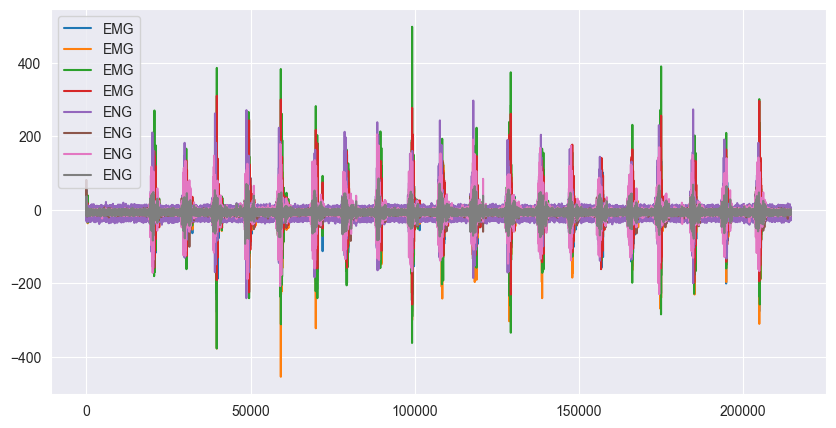

In [11]:
plt.figure(figsize=(10,5))
plt.plot(EMG_X[0].T, label='EMG')
plt.plot(ENG_X[0].T, label='ENG')
plt.legend()
plt.show()

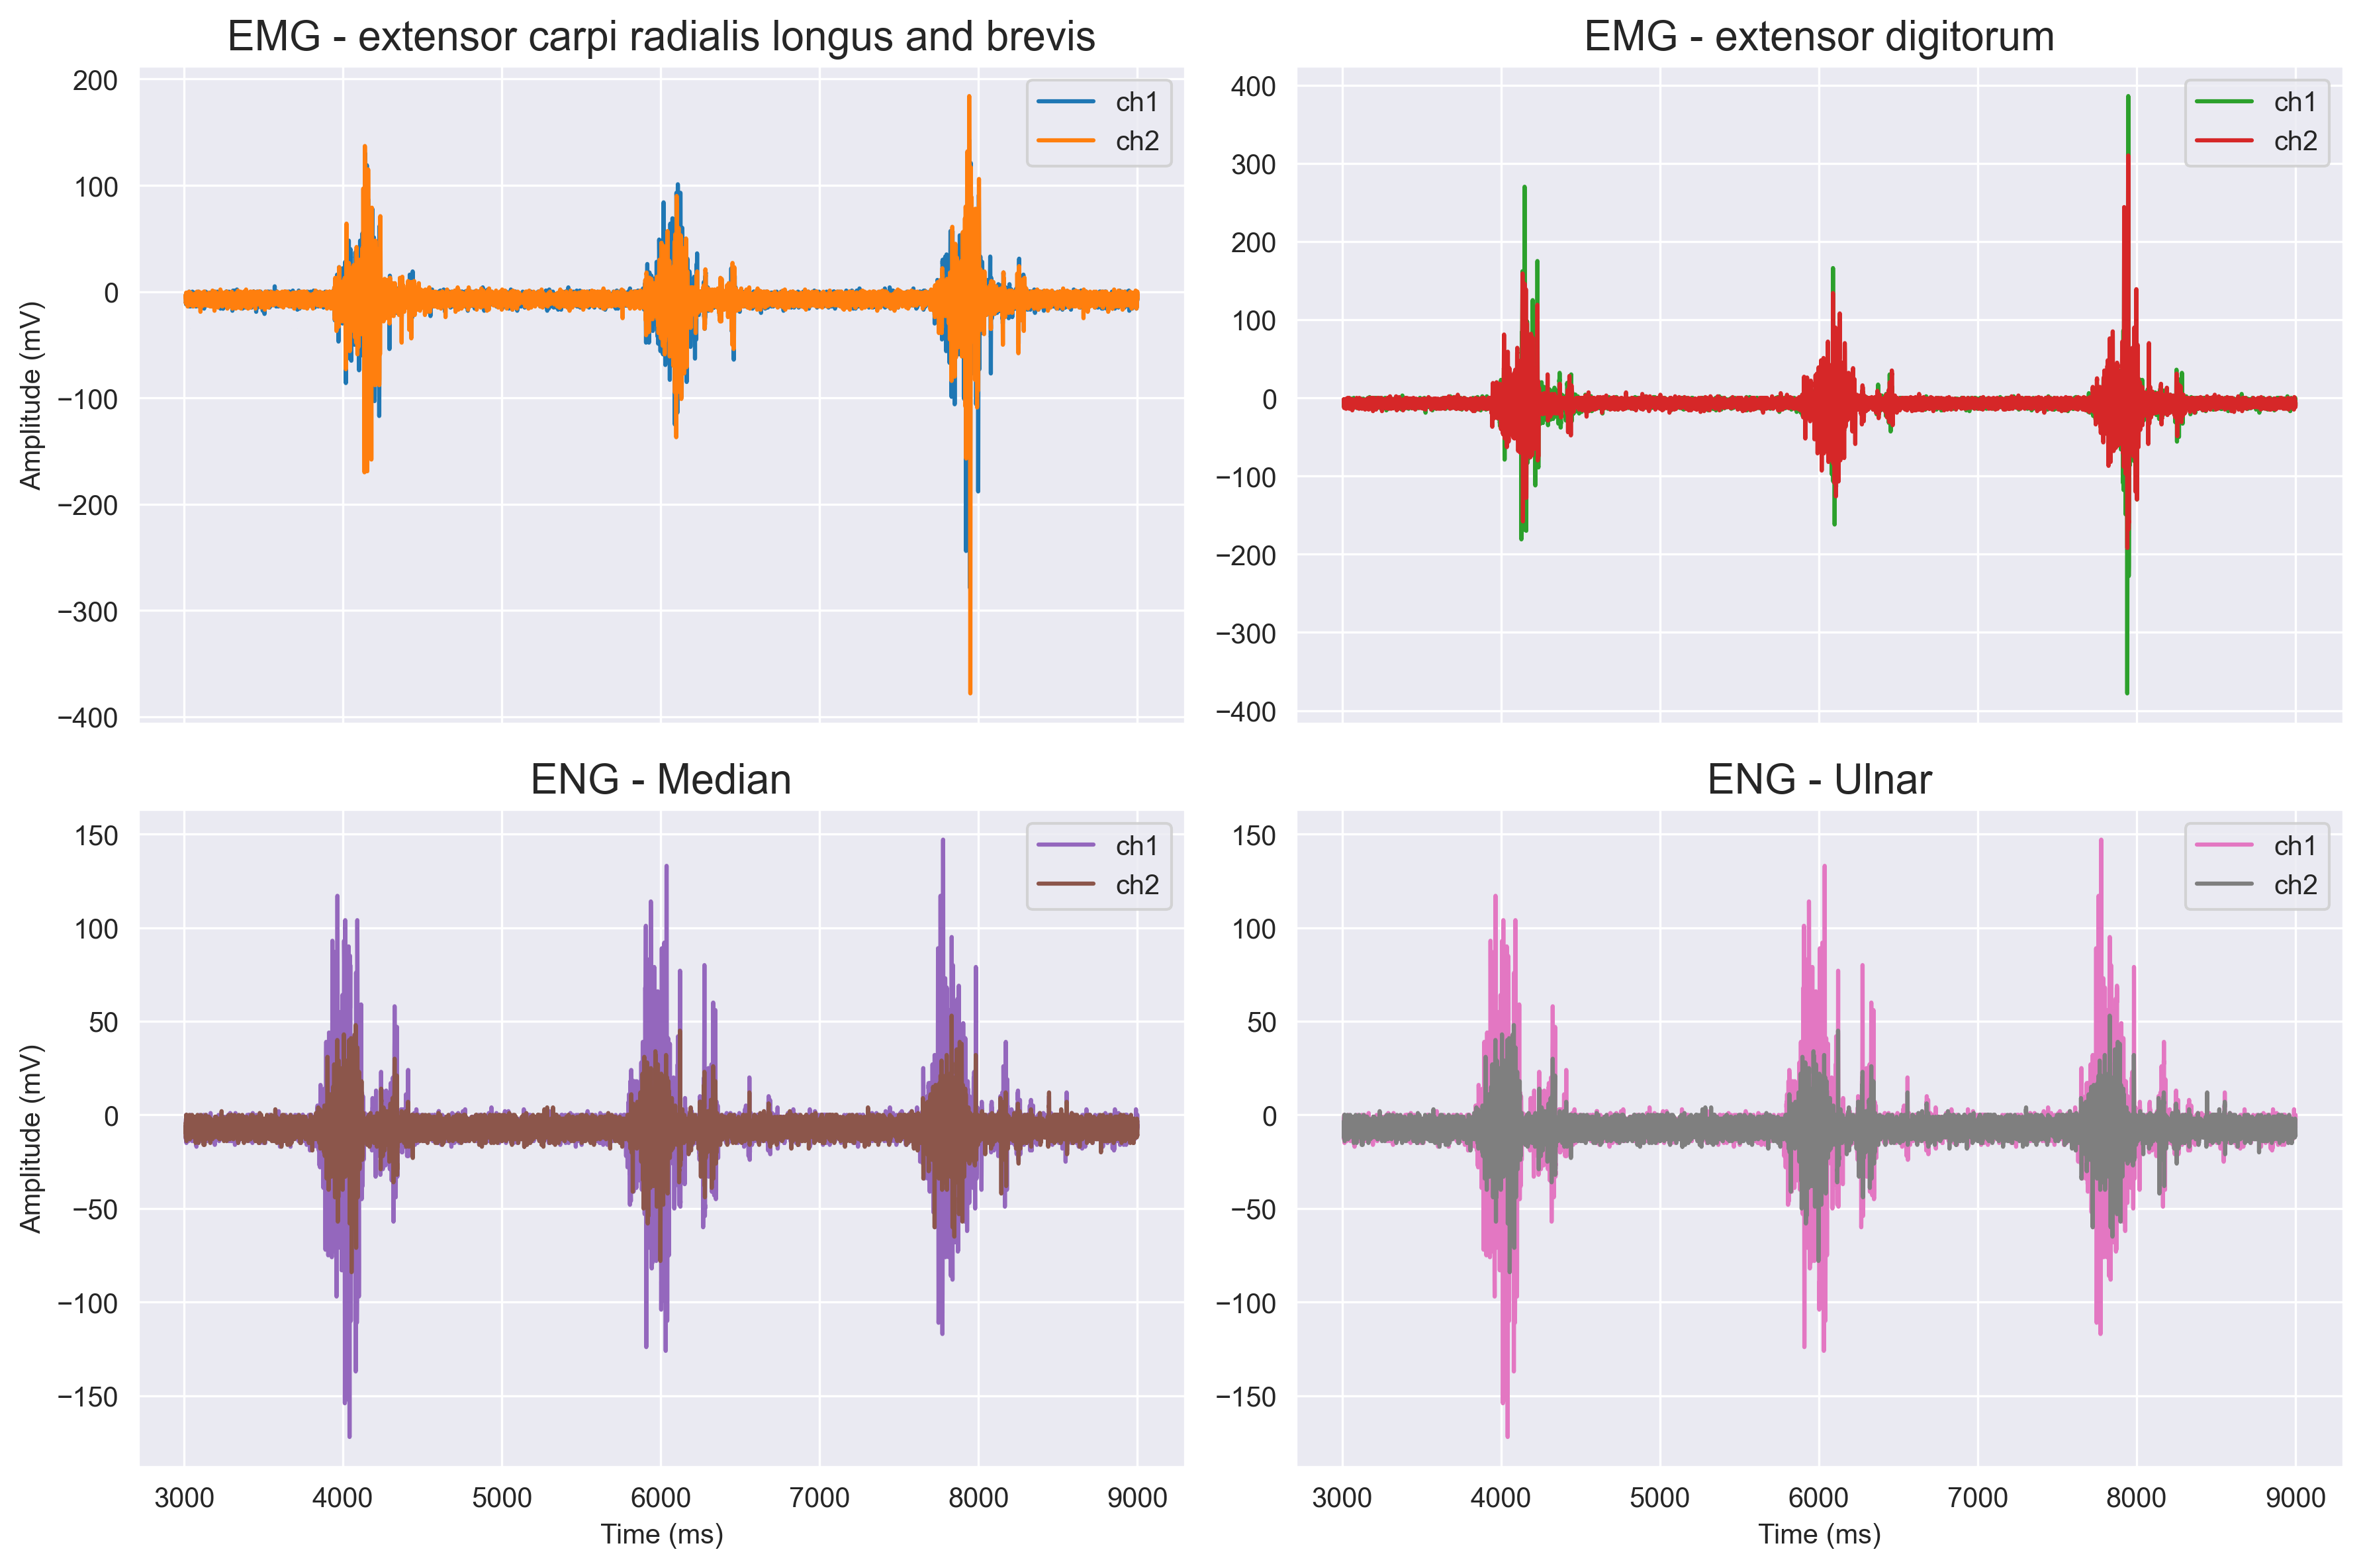

In [20]:
import matplotlib.pyplot as plt
import numpy as np

fig, axes = plt.subplots(2, 2, figsize=(12, 8), sharex=True, dpi=300)

start, end = 15050, 45000
fs = 5000  # Hz
time_ms = np.arange(start, end) / fs * 1000  # convert to ms
title_size = 15

# (0,0) EMG extensor carpi radialis longus and brevis
axes[0,0].plot(time_ms, EMG_X[0][0][start:end], color='tab:blue', label='ch1')
axes[0,0].plot(time_ms, EMG_X[0][1][start:end], color='tab:orange', label='ch2')
axes[0,0].set_title("EMG - extensor carpi radialis longus and brevis", fontsize=title_size)
axes[0,0].set_ylabel("Amplitude (mV)")
axes[0,0].legend()

# (0,1) EMG extensor digitorum
axes[0,1].plot(time_ms, EMG_X[0][2][start:end], color='tab:green', label='ch1')
axes[0,1].plot(time_ms, EMG_X[0][3][start:end], color='tab:red', label='ch2')
axes[0,1].set_title("EMG - extensor digitorum", fontsize=title_size)
axes[0,1].legend()

# (1,0) ENG Median
axes[1,0].plot(time_ms, ENG_X[0][2][start:end], color='tab:purple', label='ch1')
axes[1,0].plot(time_ms, ENG_X[0][3][start:end], color='tab:brown', label='ch2')
axes[1,0].set_title("ENG - Median", fontsize=title_size)
axes[1,0].set_xlabel("Time (ms)")
axes[1,0].set_ylabel("Amplitude (mV)")
axes[1,0].legend()

# (1,1) ENG Ulnar
axes[1,1].plot(time_ms, ENG_X[0][2][start:end], color='tab:pink', label='ch1')
axes[1,1].plot(time_ms, ENG_X[0][3][start:end], color='tab:gray', label='ch2')
axes[1,1].set_title("ENG - Ulnar", fontsize=title_size)
axes[1,1].set_xlabel("Time (ms)")
axes[1,1].legend()

plt.tight_layout()
plt.show()
